In [1]:
%load_ext autoreload
%autoreload 2

In [25]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_simload
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import matplotlib as mpl

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
S0 = jsm_ancillary.load_sample("../../data/MW/S0_fid.h5")

In [5]:
MAHs_S0 = jsm_ancillary.make_matrix(S0, "MAH")
Nsuball = jsm_ancillary.make_matrix(S0, "N_Rvir")[:, 0]
fsuball = jsm_ancillary.make_matrix(S0, "f_Rvir")[:, 0]

Nsub1st = jsm_ancillary.make_matrix(S0, "N_Rvir")[:, 2]
fsub1st = jsm_ancillary.make_matrix(S0, "f_Rvir")[:, 2]

Nsub2nd = jsm_ancillary.make_matrix(S0, "N_Rvir")[:, 4]
fsub2nd = jsm_ancillary.make_matrix(S0, "f_Rvir")[:, 4]

Nsub3rd = jsm_ancillary.make_matrix(S0, "N_Rvir")[:, 6]
fsub3rd = jsm_ancillary.make_matrix(S0, "f_Rvir")[:, 6]

In [6]:
def find_nearest1(array,value):
    idx, val = min(enumerate(array), key=lambda x: abs(x[1]-value))
    return idx

# Function to compute zX for a single history
def compute_zx(mass_history):
    mass_fracs = np.linspace(0.01, 1.0, 100)  # Mass fraction thresholds
    return np.array([cfg.zsample[find_nearest1(mass_history, mass_history[0] * mf)] for mf in mass_fracs])

In [7]:
host_zx_S0 = np.apply_along_axis(compute_zx, axis=1, arr=MAHs_S0)
host_zx_S0 = np.log10(1+host_zx_S0)

In [8]:
mass_fracs = np.linspace(0.01, 1.0, 100) 

In [9]:
Nsuball_list = []
Nsub1st_list = []
Nsub2nd_list = []
Nsub3rd_list = []

for i, frac in enumerate(mass_fracs):
    Nsuball_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], Nsuball)[0])
    Nsub1st_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], Nsub1st)[0])
    Nsub2nd_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], Nsub2nd)[0])
    Nsub3rd_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], Nsub3rd)[0])
    
Nrhoall = np.array(Nsuball_list)
Nrho1st = np.array(Nsub1st_list)
Nrho2nd = np.array(Nsub2nd_list)
Nrho3rd = np.array(Nsub3rd_list)

In [10]:
fsuball_list = []
fsub1st_list = []
fsub2nd_list = []
fsub3rd_list = []

for i, frac in enumerate(mass_fracs):
    fsuball_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], fsuball)[0])
    fsub1st_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], fsub1st)[0])
    fsub2nd_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], fsub2nd)[0])
    fsub3rd_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], fsub3rd)[0])
    
frhoall = np.array(fsuball_list)
frho1st = np.array(fsub1st_list)
frho2nd = np.array(fsub2nd_list)
frho3rd = np.array(fsub3rd_list)

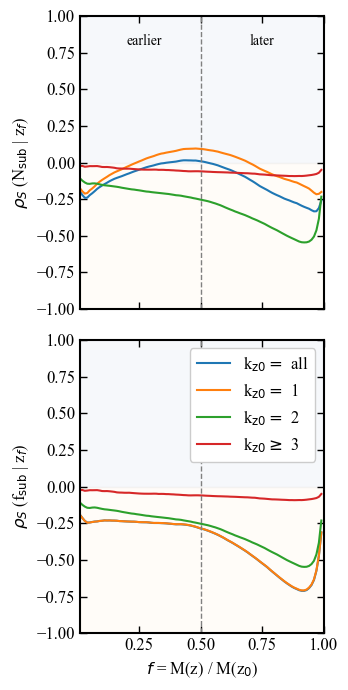

In [11]:
fig, ax = plt.subplots(2, 1,figsize=(single_textwidth,double_textwidth), sharex=True, sharey=True)

ax[0].plot(mass_fracs, Nrhoall, label='k$_{\\rm z0} =$ all', color="C0")
ax[0].plot(mass_fracs, Nrho1st, label='k$_{\\rm z0} =$ 1', color="C1")
ax[0].plot(mass_fracs, Nrho2nd, label='k$_{\\rm z0} =$ 2', color="C2")
ax[0].plot(mass_fracs, Nrho3rd, label='k$_{\\rm z0} \geq$ 3', color="C3")

ax[1].plot(mass_fracs, frhoall, label='k$_{\\rm z0} =$ all', color="C0")
ax[1].plot(mass_fracs, frho1st, label='k$_{\\rm z0} =$ 1', color="C1")
ax[1].plot(mass_fracs, frho2nd, label='k$_{\\rm z0} =$ 2', color="C2")
ax[1].plot(mass_fracs, frho3rd, label='k$_{\\rm z0} \geq$ 3', color="C3")

ax[1].legend(framealpha=1)
ax[0].set_xlim(0.01, 1)
ax[0].set_ylim(-1, 1)

ax[0].axvline(0.5, color="grey", ls="--", lw=1)
ax[1].axvline(0.5, color="grey", ls="--", lw=1, label="z$_{50}")


ax[0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_f$)")
ax[1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | z$_f$)")

ax[0].fill_between(mass_fracs, [0]*mass_fracs.shape[0], [1]*mass_fracs.shape[0], color="lightsteelblue", alpha=0.1)
ax[0].fill_between(mass_fracs, [-1]*mass_fracs.shape[0], [0]*mass_fracs.shape[0], color="bisque", alpha=0.1)

ax[1].fill_between(mass_fracs, [0]*mass_fracs.shape[0], [1]*mass_fracs.shape[0], color="lightsteelblue", alpha=0.1)
ax[1].fill_between(mass_fracs, [-1]*mass_fracs.shape[0], [0]*mass_fracs.shape[0], color="bisque", alpha=0.1)

ax[1].set_xticks([0.25, 0.5, 0.75, 1])
ax[1].set_xlabel("$f$ = M(z) / M(z$_0$)")

ax[0].text(0.2, 0.8, "earlier")
ax[0].text(0.7, 0.8, "later")

plt.tight_layout()
# plt.savefig("../../figures/z_correlation.pdf", bbox_inches="tight")
plt.show()

In [12]:
MAHs_S0 = jsm_ancillary.make_matrix(S0, "MAH")
Nsuball = jsm_ancillary.make_matrix(S0, "N_Rvir")[:, 0]
fsuball = jsm_ancillary.make_matrix(S0, "f_Rvir")[:, 0]

Nsub1st = jsm_ancillary.make_matrix(S0, "N_Rvir")[:, 1]
fsub1st = jsm_ancillary.make_matrix(S0, "f_Rvir")[:, 1]

Nsub2nd = jsm_ancillary.make_matrix(S0, "N_Rvir")[:, 3]
fsub2nd = jsm_ancillary.make_matrix(S0, "f_Rvir")[:, 3]

Nsub3rd = jsm_ancillary.make_matrix(S0, "N_Rvir")[:, 5]
fsub3rd = jsm_ancillary.make_matrix(S0, "f_Rvir")[:, 5]

In [13]:
Nsuball_list = []
Nsub1st_list = []
Nsub2nd_list = []
Nsub3rd_list = []

for i, frac in enumerate(mass_fracs):
    Nsuball_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], Nsuball)[0])
    Nsub1st_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], Nsub1st)[0])
    Nsub2nd_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], Nsub2nd)[0])
    Nsub3rd_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], Nsub3rd)[0])
    
Nrhoall = np.array(Nsuball_list)
Nrho1st = np.array(Nsub1st_list)
Nrho2nd = np.array(Nsub2nd_list)
Nrho3rd = np.array(Nsub3rd_list)

In [14]:
fsuball_list = []
fsub1st_list = []
fsub2nd_list = []
fsub3rd_list = []

for i, frac in enumerate(mass_fracs):
    fsuball_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], fsuball)[0])
    fsub1st_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], fsub1st)[0])
    fsub2nd_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], fsub2nd)[0])
    fsub3rd_list.append(jsm_stats.jackknife_correlation(host_zx_S0[:, i], fsub3rd)[0])
    
frhoall = np.array(fsuball_list)
frho1st = np.array(fsub1st_list)
frho2nd = np.array(fsub2nd_list)
frho3rd = np.array(fsub3rd_list)

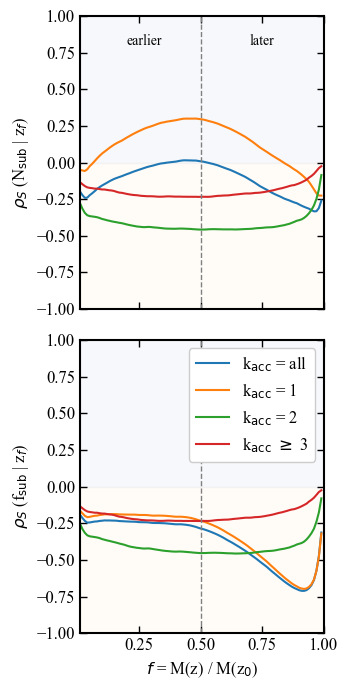

In [15]:
fig, ax = plt.subplots(2, 1,figsize=(single_textwidth,double_textwidth), sharex=True, sharey=True)

ax[0].plot(mass_fracs, Nrhoall, label='k$_{\\rm acc}$ = all', color="C0")
ax[0].plot(mass_fracs, Nrho1st, label='k$_{\\rm acc}$ = 1', color="C1")
ax[0].plot(mass_fracs, Nrho2nd, label='k$_{\\rm acc}$ = 2', color="C2")
ax[0].plot(mass_fracs, Nrho3rd, label='k$_{\\rm acc}$ $\geq$ 3', color="C3")

ax[1].plot(mass_fracs, frhoall, label='k$_{\\rm acc}$ = all', color="C0")
ax[1].plot(mass_fracs, frho1st, label='k$_{\\rm acc}$ = 1', color="C1")
ax[1].plot(mass_fracs, frho2nd, label='k$_{\\rm acc}$ = 2', color="C2")
ax[1].plot(mass_fracs, frho3rd, label='k$_{\\rm acc}$ $\geq$ 3', color="C3")

ax[1].legend(framealpha=1)

ax[0].set_xlim(0.01, 1)
ax[0].set_ylim(-1, 1)

ax[0].axvline(0.5, color="grey", ls="--", lw=1)
ax[1].axvline(0.5, color="grey", ls="--", lw=1, label="z$_{50}$")


ax[0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_f$)")
ax[1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | z$_f$)")

ax[0].fill_between(mass_fracs, [0]*mass_fracs.shape[0], [1]*mass_fracs.shape[0], color="lightsteelblue", alpha=0.1)
ax[0].fill_between(mass_fracs, [-1]*mass_fracs.shape[0], [0]*mass_fracs.shape[0], color="bisque", alpha=0.1)

ax[1].fill_between(mass_fracs, [0]*mass_fracs.shape[0], [1]*mass_fracs.shape[0], color="lightsteelblue", alpha=0.1)
ax[1].fill_between(mass_fracs, [-1]*mass_fracs.shape[0], [0]*mass_fracs.shape[0], color="bisque", alpha=0.1)

ax[1].set_xticks([0.25, 0.5, 0.75, 1])
ax[1].set_xlabel("$f$ = M(z) / M(z$_0$)")

ax[0].text(0.2, 0.8, "earlier")
ax[0].text(0.7, 0.8, "later")

plt.tight_layout()
# plt.savefig("../../figures/z_correlation.pdf", bbox_inches="tight")
plt.show()

In [26]:
host_c = S0.host_c

In [32]:
MAHs_S0 = jsm_ancillary.make_matrix(S0, "MAH")
Nsuball = jsm_ancillary.make_matrix(S0, "N_Rvir")[:, 0]
fsuball = jsm_ancillary.make_matrix(S0, "f_Rvir")[:, 0]

Nsub1st = jsm_ancillary.make_matrix(S0, "N_Rvir")[:, 2]
fsub1st = jsm_ancillary.make_matrix(S0, "f_Rvir")[:, 2]

Nsub2nd = jsm_ancillary.make_matrix(S0, "N_Rvir")[:, 4]
fsub2nd = jsm_ancillary.make_matrix(S0, "f_Rvir")[:, 4]

Nsub3rd = jsm_ancillary.make_matrix(S0, "N_Rvir")[:, 6]
fsub3rd = jsm_ancillary.make_matrix(S0, "f_Rvir")[:, 6]

In [34]:
def MAH_split(MAH_mat, sort_arr, arr_label, splitsize=1000):

    sort_mask = sort_arr.argsort()
    arr_sorted = sort_arr[sort_mask]
    MAHs_sorted = MAH_mat[sort_mask]

    num_bins = MAH_mat.shape[0] // splitsize

    arr_meds = []
    for i in range(0, len(arr_sorted), splitsize):
        med = np.average(arr_sorted[i:i+splitsize])
        arr_meds.append(med)

    arr_meds = np.array(arr_meds)

    # --- colormap ---
    norm = mpl.colors.Normalize(vmin=arr_meds.min(), vmax=arr_meds.max())
    cmap = mpl.cm.coolwarm

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])


    # --- plotting ---
    fig, ax = plt.subplots(1, 1, sharex=True, sharey=True,
                        figsize=(double_textwidth, single_textwidth))

    xvals = np.log10(1 + cfg.zsample)

    for i in range(num_bins):
        idx_start = i * splitsize
        idx_end = (i + 1) * splitsize

        # S0
        average_chunk_S0 = np.average(MAHs_sorted[idx_start:idx_end], axis=0)
        color_S0 = cmap(norm(arr_meds[i]))
        ax.plot(xvals, average_chunk_S0, color=color_S0, lw=1.5)


    ax.set_yscale("log")  # crucial for absolute mass
    ax.set_xlim(0.6, 0)
    ax.set_ylim(9e10,2e12)

    # --- colorbar ---
    plt.subplots_adjust(top=0.98)
    cbar_ax = fig.add_axes([0.17, 1.11, 0.7, 0.02])

    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(arr_label, loc="center")

    ax.set_xlabel("log (1 + z)")
    ax.set_ylabel("M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")
    # plt.tight_layout()
    plt.show()


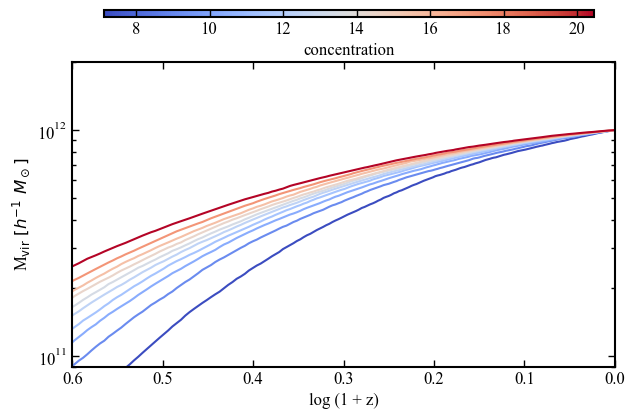

In [36]:
MAH_split(MAHs_S0, host_c, "concentration")

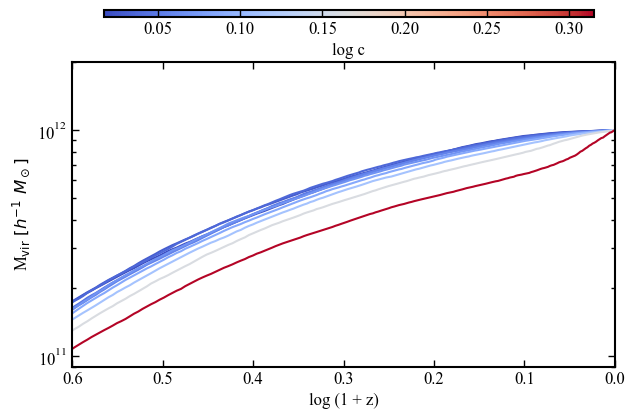

In [37]:
MAH_split(MAHs_S0, fsuball, "log c")

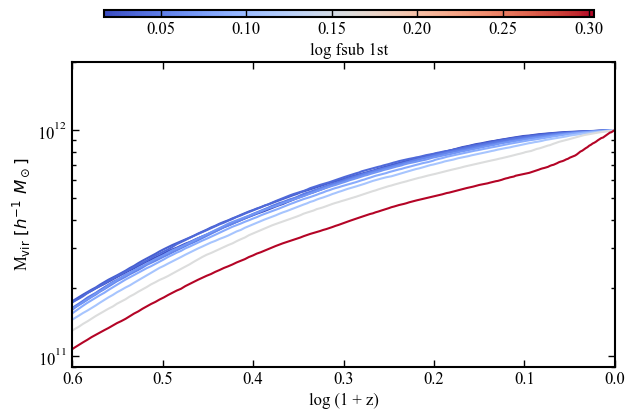

In [38]:
MAH_split(MAHs_S0, fsub1st, "log fsub 1st")

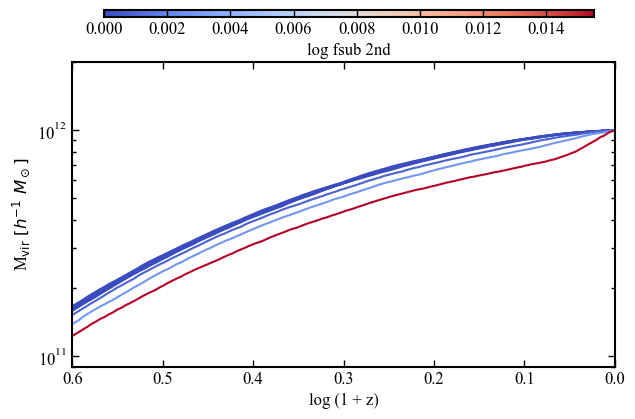

In [39]:
MAH_split(MAHs_S0, fsub2nd, "log fsub 2nd")

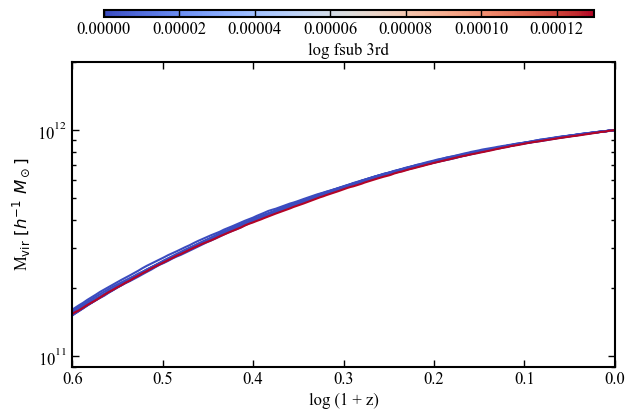

In [40]:
MAH_split(MAHs_S0, fsub3rd, "log fsub 3rd")

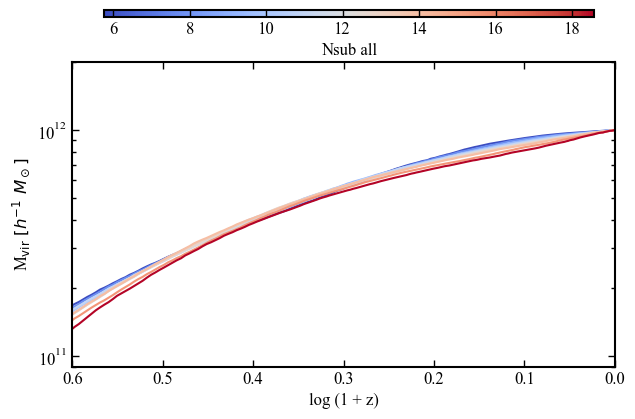

In [41]:
MAH_split(MAHs_S0, Nsuball, "Nsub all")

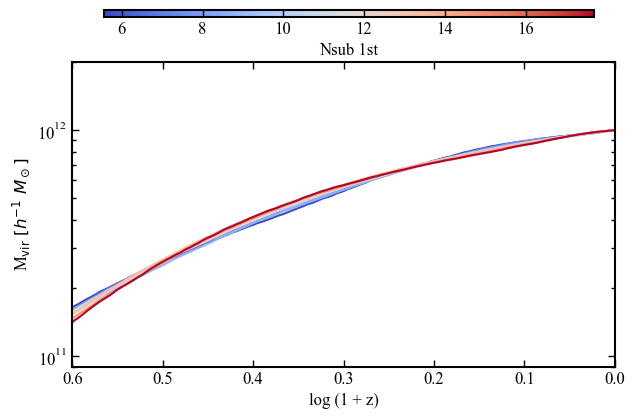

In [42]:
MAH_split(MAHs_S0, Nsub1st, "Nsub 1st")

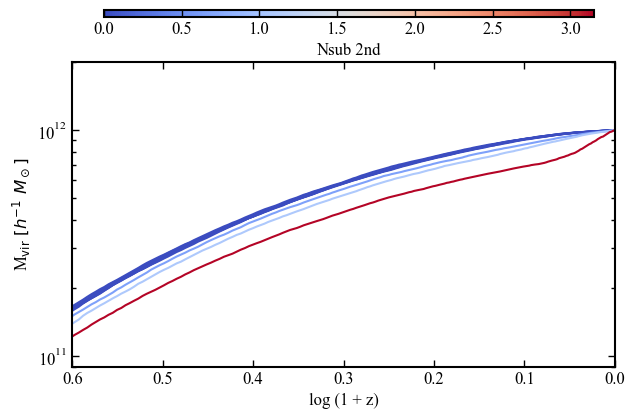

In [43]:
MAH_split(MAHs_S0, Nsub2nd, "Nsub 2nd")

In [ ]:
sns.kdeplot(Nsuball)
sns.kdeplot(Nsub1st)
sns.kdeplot(Nsub2nd)
sns.kdeplot(Nsub3rd)
plt.ylim(0, 1)
plt.xlim(0, 20)

In [ ]:
sns.kdeplot(np.log10(fsuball))
sns.kdeplot(np.log10(fsub1st))
sns.kdeplot(np.log10(fsub2nd))
sns.kdeplot(np.log10(fsub3rd))
plt.ylim(0, 1)
plt.xlim(-3, 0)

In [ ]:
sns.kdeplot(x=host_zx_S0[:, 0], y=Nsuball, levels=levelz)
sns.kdeplot(x=host_zx_S0[:, 49], y=Nsuball, levels=levelz)
sns.kdeplot(x=host_zx_S0[:, 98], y=Nsuball, levels=levelz)

In [ ]:
sns.kdeplot(x=host_zx_S0[:, 0], y=np.log10(fsuball), levels=levelz)
sns.kdeplot(x=host_zx_S0[:, 49], y=np.log10(fsuball), levels=levelz)
sns.kdeplot(x=host_zx_S0[:, 98], y=np.log10(fsuball), levels=levelz)